# Notes

* are there still those blibs at SXF? Are there also during the day? Do we take hourly images of the site?
* I just reinstalled my recent changes, are the gaps still there?

In [24]:
plt.rcParams['figure.dpi'] = 200

# 1 week of Housekeeping

# 1 week one all channel at all sites

## raw2netcdf

In [25]:
version = '0.4'
days = 5
# p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2026/
# p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/v0.3/2026/
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v{version}/2026/'
p2fld_rad = '/Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/{site}/2026/'
# [s.name for s in list(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/').glob('*'))]

# Load data
sites = ['inl','gwn', 'psu', 
         'sxf', 'tbl', 'bnd', 'fpe', 'dra'
        ]
data = {}

for e,s in enumerate(sites):
    out = {}
    # print(s)
    ### mfrsr
    if 1:
        fl = list(pl.Path(p2fld.format(site = s, version = version)).glob('*.nc'))
        fl.sort()
        with xr.open_mfdataset(fl[- days:]) as rein:
            ds = rein.load()
        out['mfrsr'] = ds
        data[s] = out
    if 1:
        if s == 'bnd':
            st = 'bon'
        elif s == 'fpe':
            st = 'fpk'
        else:
            st = s
        fl = list(pl.Path(p2fld_rad.format(site = st)).glob('*.nc'))
        fl.sort()
        try:
            with xr.open_mfdataset(fl[- days:]) as rein:
                ds = rein.load()
            out['rad'] = ds
            data[s] = out
        except:
            print(f'Problem: {s} has not radiation')
    ## radiation
pd.Timestamp.now()

Timestamp('2026-05-08 14:28:01.673549')

In [26]:
# %matplotlib 

inl has no radiation data


/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_33011/551912856.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend().remove()


Timestamp('2026-05-08 14:28:01.767887')

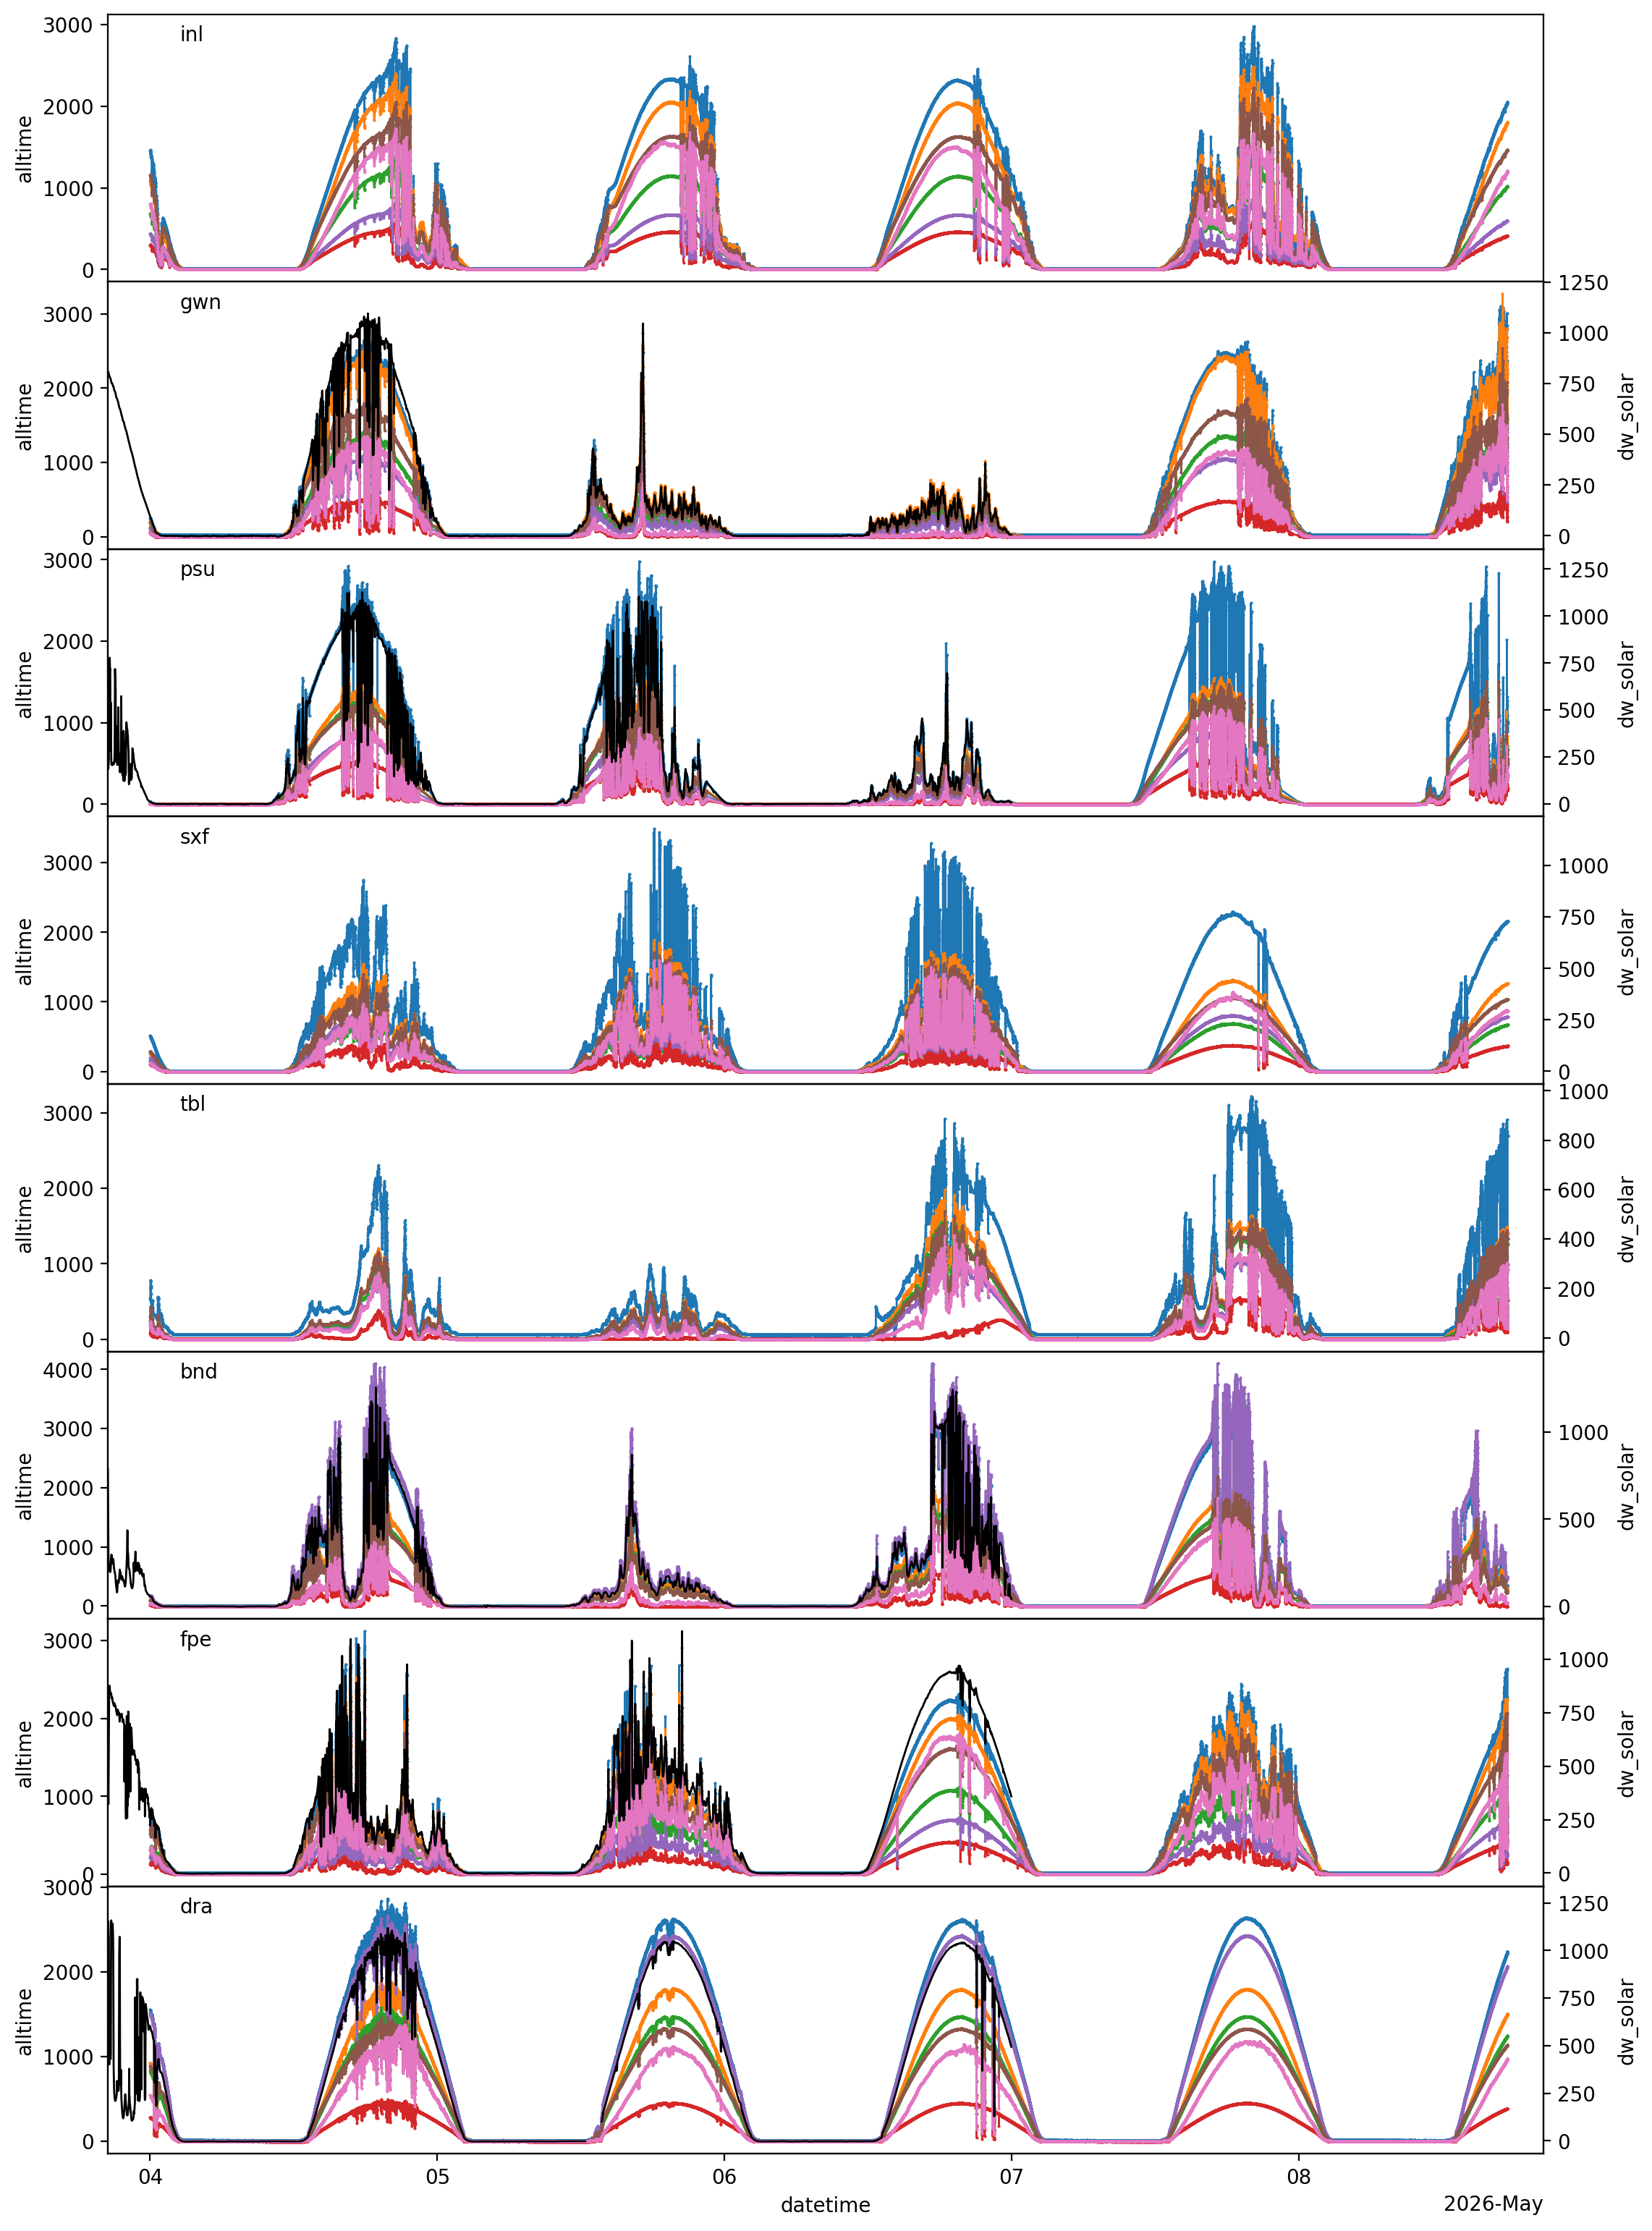

In [27]:
f, aa = plt.subplots(len(data.keys()), sharex=True, gridspec_kw={'hspace': 0})
f.set_figheight(f.get_figheight() * len(data.keys()) * 0.5)
f.set_figwidth(f.get_figwidth() *2)
                
for e,s in enumerate(data):
    a = aa[e]
    ds  = data[s]['mfrsr']
    ds.alltime.plot.line(x='datetime', ax = a, lw = 1, ls = '-', marker = '.', markersize = 1)
    a.legend().remove()
    a.text(0.05, 0.9, s, transform = a.transAxes)

    if 1:
        try:
            ds = data[s]['rad']
            at = a.twinx()
            ds.dw_solar.plot(ax = at, color = 'black', lw = 1)
        except KeyError:
            print(f'{s} has no radiation data')

end = pd.Timestamp.now(tz = 'UTC')
start = end - pd.to_timedelta(days, 'D')
aa[-1].set_xlim(start, end)
pd.Timestamp.now()

KeyError: 'rad'

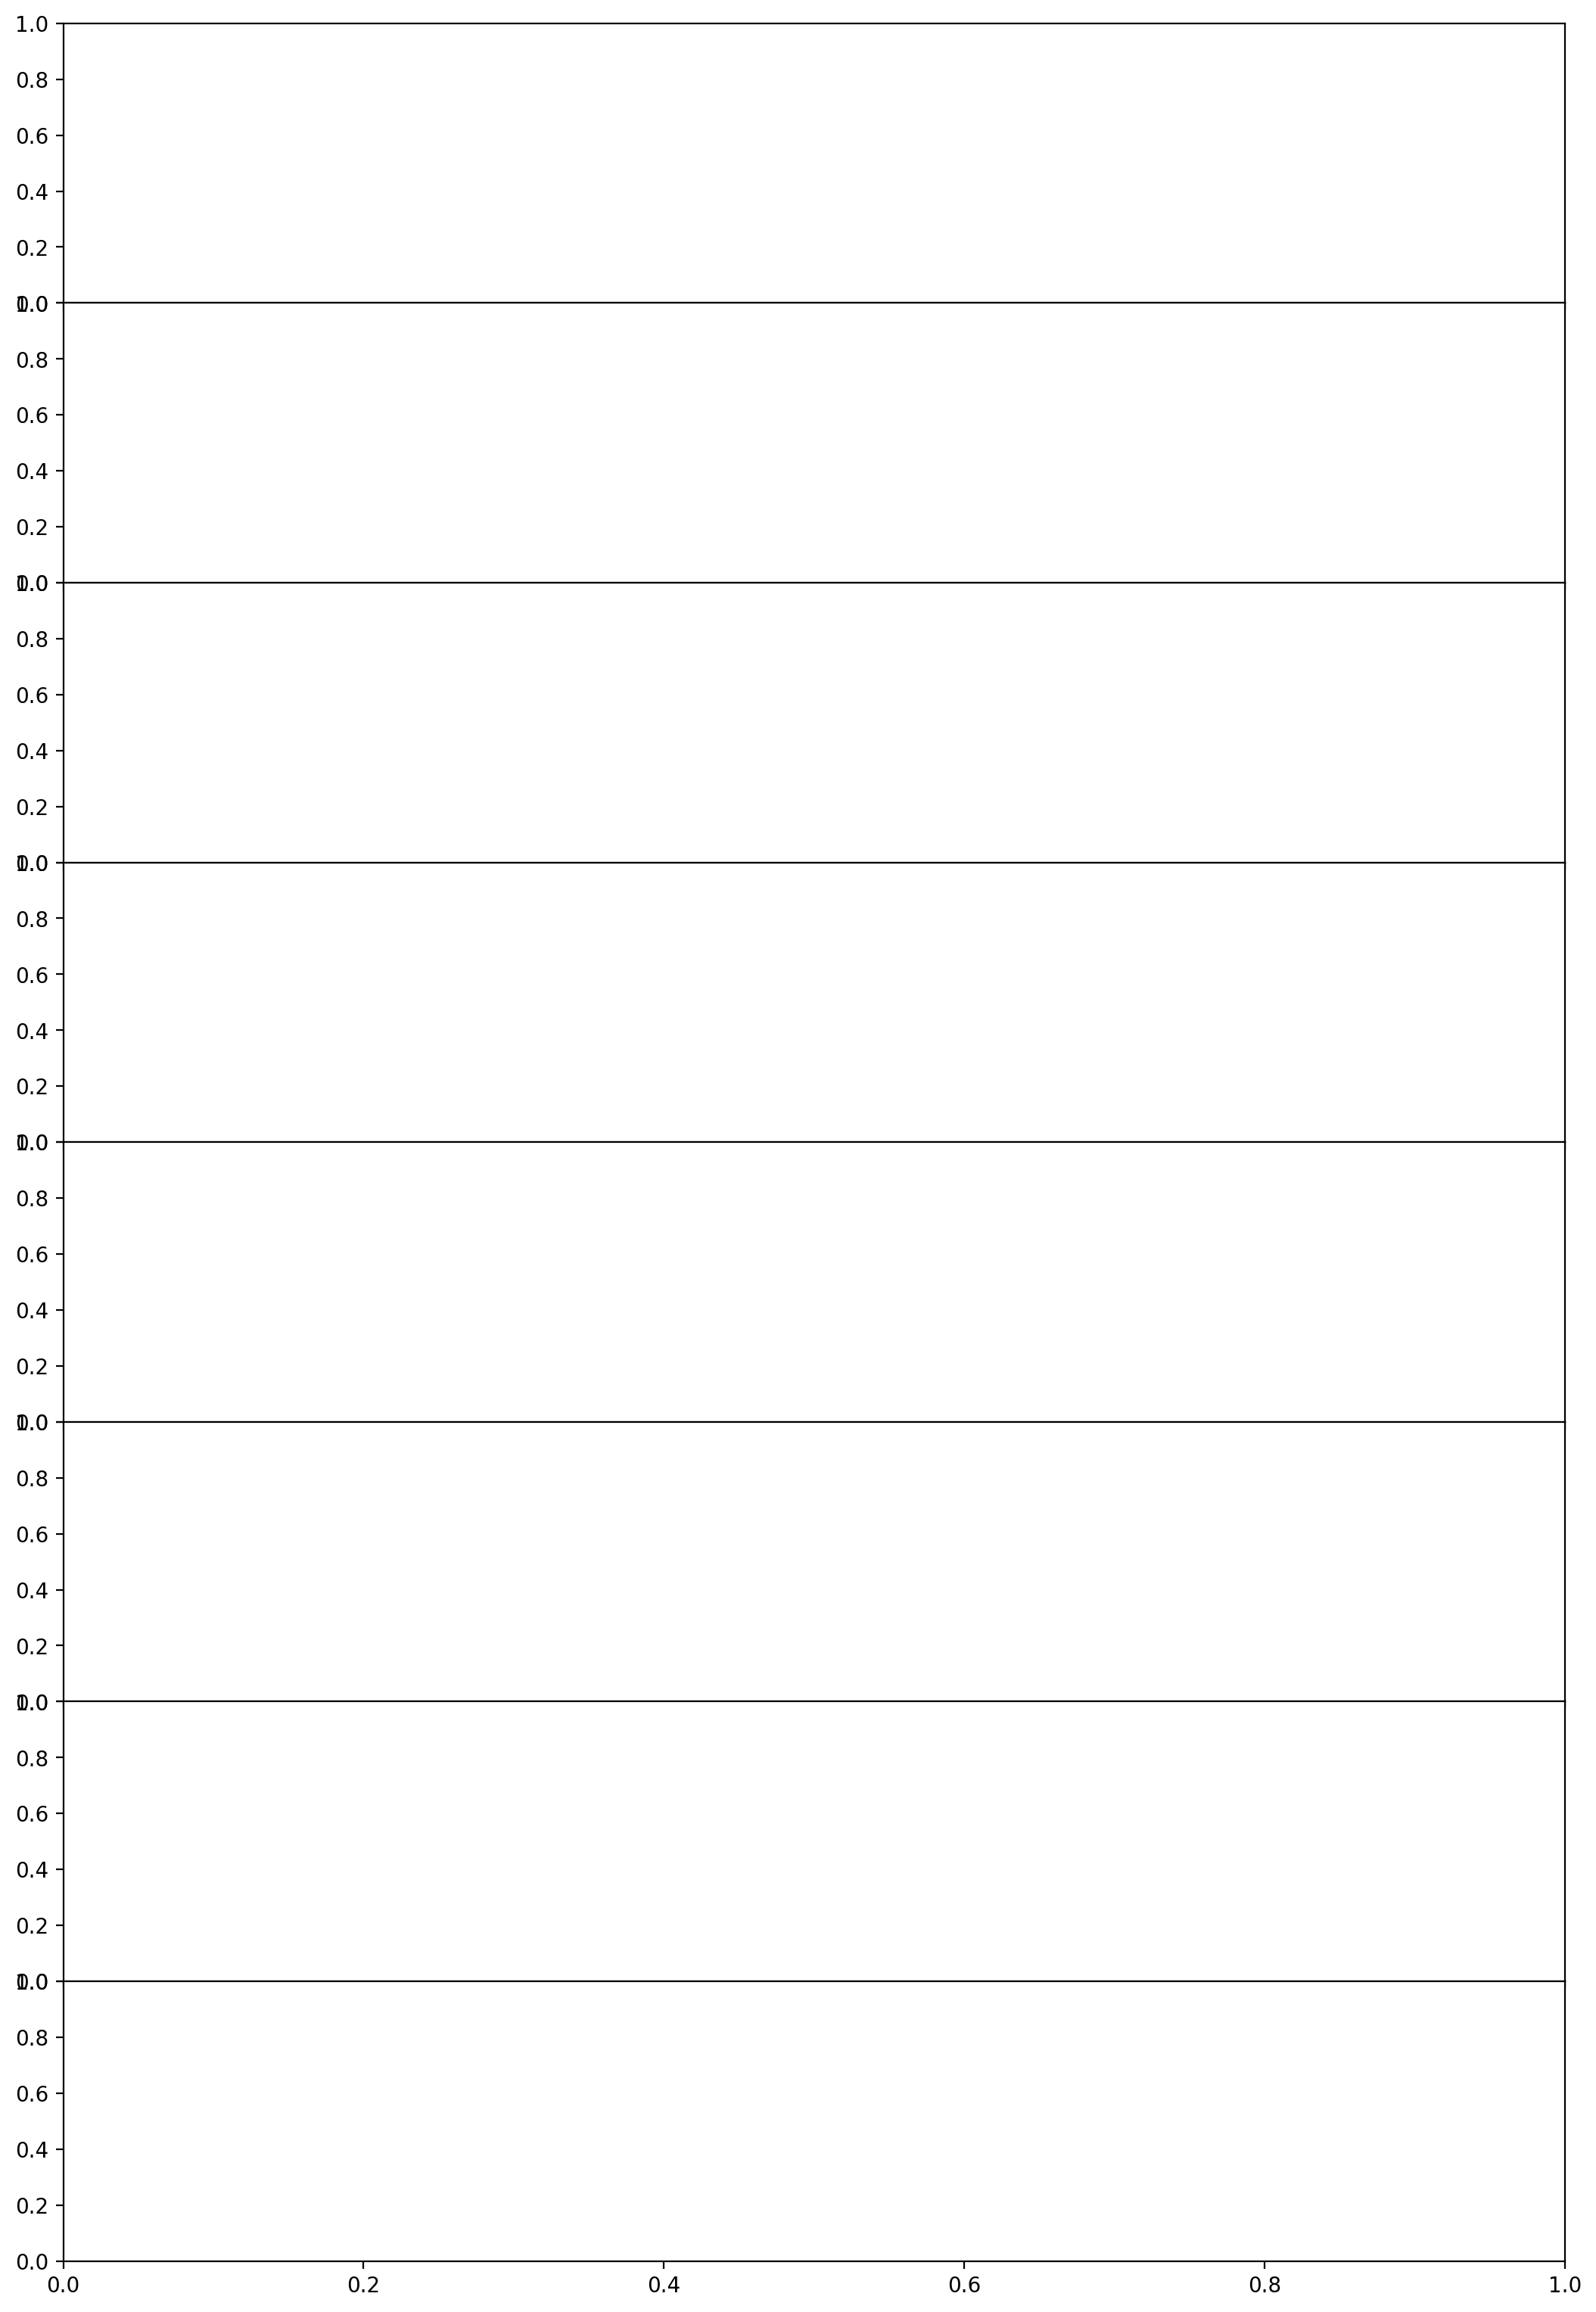

In [28]:
f, aa = plt.subplots(len(data.keys()), sharex=True, gridspec_kw={'hspace': 0})
f.set_figheight(f.get_figheight() * len(data.keys()) * 0.5)
f.set_figwidth(f.get_figwidth() *2)
                
for e,s in enumerate(data):
    a = aa[e]
    ds  = data[s]['mfrsr']
    dsr = data[s]['rad']
    (ds.alltime.sel(channel = 1) / dsr.dw_solar).plot(ax = a, lw = 1, ls = '', marker = '.', markersize = 1)
    a.legend().remove()
    a.text(0.05, 0.9, s, transform = a.transAxes)

end = pd.Timestamp.now(tz = 'UTC')
start = end - pd.to_timedelta(days, 'D')
aa[-1].set_xlim(start, end)
for a in aa:
    a.set_ylim(1,3)
pd.Timestamp.now()

In [ ]:
f, aa = plt.subplots(len(data.keys()), sharex=True, gridspec_kw={'hspace': 0})
f.set_figheight(f.get_figheight() * len(data.keys()) * 0.5)
f.set_figwidth(f.get_figwidth() *2)
                
for e,s in enumerate(data):
    a = aa[e]
    ds  = data[s]['mfrsr']
    ds.alltime.sel(channel = 0).plot(ax = a, lw = 1, ls = '', marker = '.', markersize = 1)
    a.legend().remove()
    a.text(0.05, 0.9, s, transform = a.transAxes)

    if 1:
        ds = data[s]['rad']
        at = a.twinx()
        ds.dw_solar.plot(ax = at, color = 'black', lw = 1)

end = pd.Timestamp.now(tz = 'UTC')
start = end - pd.to_timedelta(days, 'D')
aa[-1].set_xlim(start, end)

In [ ]:
assert(False), 'STOP!!!'

## Trouble shooteing

# problem: does miss the first chunck of the tay



questions:
- did something change, like the time when the data is pulled

culprit:
- data recording switched to hourly!
- probably the fact that the time-stamp of the file is different than the data in the file

todo:
- check if there is an issue with the raw
- what had changed that now it is an issue befor was fine?!?
- establish the issu

### is there an issue with the raw

In [ ]:
import surfradpy.file_io.mfrsr as mfrio

In [ ]:
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026')
l = list(p2fld.glob('*20260426*'))
l.sort()
l

In [ ]:
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/psu/mfrsr/raw/2026')
l = list(p2fld.glob('*20260426*'))
l.sort()
l

In [ ]:
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/raw/2026')
l = list(p2fld.glob('*20260426*'))
l.sort()
l

In [ ]:
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026')
l = list(p2fld.glob('*20260429*'))
l.sort()
l

### just the first of 29

In [ ]:
dss003024 = mfrio.open_rsr('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026/tbl_mfrsr_20260429_003024.xmd').dataset

In [ ]:
dt = pd.to_datetime('20260429 00:30:24').tz_localize('America/Denver')
dt.tz_convert('UTC')

In [ ]:
dt = pd.to_datetime('20260129 00:30:24').tz_localize('America/Denver')
dt.tz_convert('UTC')

In [ ]:
dss

In [ ]:
dss.sel(channel = 2).alltime.plot()

In [ ]:
p = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026/tbl_mfrsr_20260429_003024.xmd')
dt = pd.to_datetime(p.stem.split('_')[2] + '_' + p.stem.split('_')[3],
                    format='%Y%m%d_%H%M%S')
dt

In [ ]:
p = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/raw/2026/dra_mfrsr_20260429_003001.xmd')
dt = pd.to_datetime(p.stem.split('_')[2] + '_' + p.stem.split('_')[3],
                    format='%Y%m%d_%H%M%S')
dt

# timestamp strange

* The files all have the same timestamp. 
* If the timestamp is LST it should provide provide different time ranges
* likely this means the time
* This should is reverted back to the old behaviour in later changes (early 04/30)


(py313) htelg@pulsar5:/nfs/grad/Inst/MFR/SURFRAD$ ll dra/mfrsr/raw/2026/*20260429_00*; ll tbl/mfrsr/raw/2026/*20260429_00*;ll psu/mfrsr/raw/2026/*20260429_00*
-r--r----- 1 mfrsr7 grad 3.3K Apr 29 00:30 dra/mfrsr/raw/2026/dra_mfrsr_20260429_003001.xmd
-r--r----- 1 mfrsr7 grad 3.3K Apr 29 00:30 tbl/mfrsr/raw/2026/tbl_mfrsr_20260429_003024.xmd
-r--r----- 1 mfrsr7 grad 3.3K Apr 29 00:30 psu/mfrsr/raw/2026/psu_mfrsr_20260429_003001.xmd

dsstbl = mfrio.open_rsr('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026/tbl_mfrsr_20260429_003024.xmd').dataset

In [ ]:
dssdra = mfrio.open_rsr('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/raw/2026/dra_mfrsr_20260429_003001.xmd').dataset

In [ ]:
dsspsu = mfrio.open_rsr('/Volumes/grad/Inst/MFR/SURFRAD/psu/mfrsr/raw/2026/psu_mfrsr_20260429_003001.xmd').dataset

In [ ]:
dsstbl.sel(channel = 2).alltime.plot()
dssdra.sel(channel = 2).alltime.plot()
dsspsu.sel(channel = 2).alltime.plot()

## what was it before?

I belive this indicates that it was it was LST was the normal belore the recent changes


(py313) htelg@pulsar5:/nfs/grad/Inst/MFR/SURFRAD$ ll dra/mfrsr/raw/2026/*20260427* | tail -n 1; ll tbl/mfrsr/raw/2026/*202
60427* | tail -n 1; ll psu/mfrsr/raw/2026/*20260427* | tail -n 1
-r--r----- 1 mfrsr7 grad 49K Apr 27 12:22 dra/mfrsr/raw/2026/dra_mfrsr_20260427_100214.xmd
-r--r----- 1 mfrsr7 grad 56K Apr 27 12:22 tbl/mfrsr/raw/2026/tbl_mfrsr_20260427_111438.xmd
-r--r----- 1 mfrsr7 grad 56K Apr 27 12:22 psu/mfrsr/raw/2026/psu_mfrsr_20260427_131002.xmd


## behaviou now

This indicates to me that it is LST again?

(py313) htelg@pulsar5:/nfs/grad/Inst/MFR/SURFRAD$ ll dra/mfrsr/raw/2026/*20260430* | tail -n 1; ll tbl/mfrsr/raw/2026/*202
60430* | tail -n 1; ll psu/mfrsr/raw/2026/*20260430* | tail -n 1
-r--r----- 1 mfrsr7 grad 1.5K Apr 30 12:30 dra/mfrsr/raw/2026/dra_mfrsr_20260430_103022.xmd
-r--r----- 1 mfrsr7 grad 1.4K Apr 30 12:30 tbl/mfrsr/raw/2026/tbl_mfrsr_20260430_113040.xmd
-r--r----- 1 mfrsr7 grad 1.4K Apr 30 12:30 psu/mfrsr/raw/2026/psu_mfrsr_20260430_133041.xmd

In [ ]:
dst = mfrio.open_rsr('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/raw/2026/dra_mfrsr_').dataset

In [ ]:
dst.sel(channel = 2).alltime.plot()

### plot a single one

In [ ]:
%matplotlib widget

In [ ]:
f, a = plt.subplots()#len(data.keys()), sharex=True, gridspec_kw={'hspace': 0})
# f.set_figheight(f.get_figheight() * len(data.keys()) * 0.5)
# f.set_figwidth(f.get_figwidth() *2)
                
for e,s in enumerate(data):
    if s != 'sxf':
        continue
    # a = aa[e]
    ds  = data[s]['mfrsr']
    ds.alltime.sel(channel = 0).plot(ax = a, lw = 1, ls = '-', marker = '.', markersize = 1)
    a.legend().remove()
    a.text(0.05, 0.9, s, transform = a.transAxes)
    if 1:
        ds = data[s]['rad']
        at = a.twinx()
        # ds.head_temperature.plot(ax = at, lw = 1, ls = '', marker = '.', markersize = 1, color = 'red')
        ds.dw_solar.plot(ax = at, color = 'black', lw = 1)
        # ds.dw_ir.plot(ax = at, color = 'black', lw = 1)


end = pd.Timestamp.now(tz = 'UTC')
start = end - pd.to_timedelta(days, 'D')
aa[-1].set_xlim(start, end)

In [ ]:
f.show()

### list some files

In [ ]:
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/gwn/mfrsr/raw/2026')
l = list(p2fld.glob('*'))
l.sort()
l

## tu

In [ ]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [ ]:
days = 7
# p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2026/
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/tu/2026/'


In [ ]:
sites = ['gwn', 'psu', 
         'sxf', 'tbl', 'bnd', 'fpe', 'dra'
        ]
data = {}
for s in sites:
    # print(s)
    fl = list(pl.Path(p2fld.format(site = s)).glob('*'))
    fl.sort()
    fl = fl[- days:]
    flds = []
    for f in fl:
        tmp = atmsrf.read_ccc(f, raisefilterfunctionerror=False)
        flds.append(tmp.dataset)
    ds = xr.concat(flds, 'datetime')
    data[s] = ds

In [ ]:
f, aa = plt.subplots(len(data.keys()), sharex=True, gridspec_kw={'hspace': 0})
for e,s in enumerate(data):
    a = aa[e]
    ds  = data[s]
    ds.all_time.plot.line(x='datetime', ax = a, lw = 1)
    a.legend().remove()
    a.text(0.05, 0.9, s, transform = a.transAxes)

end = pd.Timestamp.now(tz = 'UTC')
start = end - pd.to_timedelta(days, 'D')
aa[-1].set_xlim(start, end)

In [ ]:
ds

# Toold

## Delete all raw netcdf data in last x days (this will trigger reprocessing)

In [ ]:
version = '0.3'
days = 4
# p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2026/
# p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/v0.3/2026/
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v{version}/2026/'

In [ ]:
# Load data
if 0:
    sites = ['gwn', 'psu', 
             'sxf', 'tbl', 'bnd', 'fpe', 'dra'
            ]
    data = {}
    for s in sites:
        # print(s)
        fl = list(pl.Path(p2fld.format(site = s, version = version)).glob('*.nc'))
        fl.sort()
        
        fl = fl[- days:]
        for p2f in fl:
            p2f.unlink()
        # ds = xr.open_mfdataset(fl[- days:])
        
        # data[s] = ds